Chr1 length: 30,427,671 bp

Centromere region  (smoothed repeat score > 0.05):
  Start  :   14,270,000 bp   (14.27 Mb)
  End    :   15,700,000 bp   (15.70 Mb)
  Length :    1,430,000 bp   (1.43 Mb)

Suggested --positions for pipeline:
  Outside centromere : 10000000  20000000
  Inside  centromere : 15000000  (15 Mb)

Already simulated:
  pos10mb         10,000,000 bp  (10 Mb)  — outside centromere
  pos20mb         20,000,000 bp  (20 Mb)  — outside centromere
  pos30mb         30,000,000 bp  (30 Mb)  — outside centromere


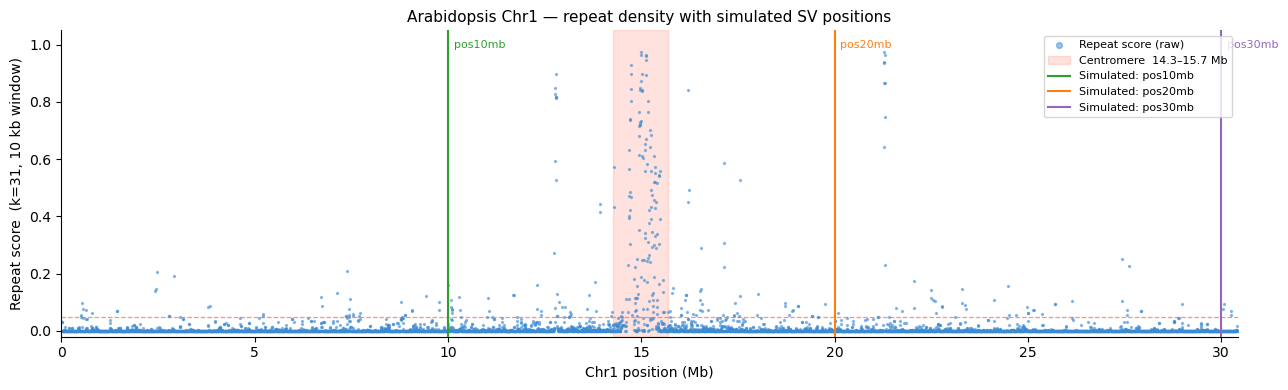

Saved chr1_repeat_score.pdf


In [2]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ── parameters ───────────────────────────────────────────────────────────────
FASTA          = "/Users/tatiana/Documents_new/visor_freqk/data/reference/Chr1.fa"
WINDOW         = 10_000   # bp per window
STEP           =  5_000   # step between windows
K              =     31   # k-mer size (matches short-read seed)
CENTRO_THRESH  =   0.05   # repeat-score threshold for calling a window centromeric
                           # (lowered: pericentromere has many windows just above 0.05)
SMOOTH_BP      = 200_000  # Gaussian smoothing width (bp) before centromere detection

# ── positions already simulated ──────────────────────────────────────────────
# Add / remove positions (bp, 0-based) as you run more experiments
SIMULATED = {
    "pos10mb": 10_000_000,
    "pos20mb": 20_000_000,
    "pos30mb": 30_000_000
}

# ── repeat score: fraction of k-mers appearing > 1 time within the window ───
def repeat_score(seq, k=K):
    seq   = seq.replace("N", "")
    total = len(seq) - k + 1
    if total <= 0:
        return np.nan
    counts   = Counter(seq[i : i + k] for i in range(total))
    repeated = sum(v for v in counts.values() if v > 1)
    return repeated / total

# ── load & scan ───────────────────────────────────────────────────────────────
record    = next(SeqIO.parse(FASTA, "fasta"))
seq       = str(record.seq).upper()
chrom_len = len(seq)
print(f"Chr1 length: {chrom_len:,} bp")

mids, scores = [], []
for i in range(0, chrom_len - WINDOW, STEP):
    w = seq[i : i + WINDOW]
    if w.count("N") / WINDOW > 0.5:
        continue
    mids.append(i + WINDOW // 2)
    scores.append(repeat_score(w))

mids   = np.array(mids)
scores = np.array(scores)

# ── smooth scores before centromere detection ────────────────────────────────
sigma_windows = max(1, round(SMOOTH_BP / STEP))
from scipy.ndimage import gaussian_filter1d
scores_smooth = gaussian_filter1d(scores, sigma=sigma_windows)

# ── detect centromere: largest contiguous run of high-repeat windows ──────────
above = scores_smooth > CENTRO_THRESH
runs, in_run = [], False
for j, v in enumerate(above):
    if v and not in_run:
        run_start = j;  in_run = True
    elif not v and in_run:
        runs.append((run_start, j - 1)); in_run = False
if in_run:
    runs.append((run_start, len(above) - 1))

longest      = max(runs, key=lambda r: r[1] - r[0])
centro_start = mids[longest[0]] - WINDOW // 2
centro_end   = mids[longest[1]] + WINDOW // 2

print(f"\nCentromere region  (smoothed repeat score > {CENTRO_THRESH}):")
print(f"  Start  : {centro_start:>12,} bp   ({centro_start / 1e6:.2f} Mb)")
print(f"  End    : {centro_end:>12,} bp   ({centro_end   / 1e6:.2f} Mb)")
print(f"  Length : {centro_end - centro_start:>12,} bp   ({(centro_end - centro_start) / 1e6:.2f} Mb)")

inside_mb  = round((centro_start + centro_end) / 2 / 1e6)
inside_pos = inside_mb * 1_000_000
print(f"\nSuggested --positions for pipeline:")
print(f"  Outside centromere : 10000000  20000000")
print(f"  Inside  centromere : {inside_pos}  ({inside_mb} Mb)")

print(f"\nAlready simulated:")
for label, pos in SIMULATED.items():
    in_centro = centro_start <= pos <= centro_end
    region = "INSIDE centromere" if in_centro else "outside centromere"
    print(f"  {label:12s}  {pos:>12,} bp  ({pos/1e6:.0f} Mb)  — {region}")

# ── single plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

# raw repeat score
ax.scatter(mids / 1e6, scores, s=2, c="#3B8BD4", alpha=0.5, rasterized=True, zorder=2, label="Repeat score (raw)")

# centromere shading
ax.axvspan(centro_start / 1e6, centro_end / 1e6,
           alpha=0.18, color="tomato", zorder=1,
           label=f"Centromere  {centro_start/1e6:.1f}–{centro_end/1e6:.1f} Mb")
ax.axhline(CENTRO_THRESH, color="tomato", lw=0.9, ls="--", alpha=0.7)

# simulated positions
SIM_COLORS = ["#2ca02c", "#ff7f0e", "#9467bd", "#8c564b", "#e377c2"]
for (label, pos), color in zip(SIMULATED.items(), SIM_COLORS):
    ax.axvline(pos / 1e6, color=color, lw=1.5, ls="-", zorder=3, label=f"Simulated: {label}")
    ax.text(pos / 1e6 + 0.15, 0.97, label,
            color=color, fontsize=8, va="top", transform=ax.get_xaxis_transform())

ax.set_xlim(0, chrom_len / 1e6)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("Chr1 position (Mb)", fontsize=10)
ax.set_ylabel(f"Repeat score  (k={K}, {WINDOW//1000} kb window)", fontsize=10)
ax.set_title("Arabidopsis Chr1 — repeat density with simulated SV positions", fontsize=11)
ax.legend(fontsize=8, loc="upper right", markerscale=3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("chr1_repeat_score.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved chr1_repeat_score.pdf")